# EDA — E-Commerce Customer Churn Dataset

**Objective:** Understand distributions, class imbalance, and key churn predictors before building the ML pipeline.

**Dataset:** E-Commerce Customer Churn — 8,500 customers, 22 features, 16.9% churn rate

In [1]:
import sys
sys.path.insert(0, "../..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from training.src.data_loader import EcommerceChurnDataLoader

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)

loader = EcommerceChurnDataLoader()  # default: Data/raw/ecommerce_churn.csv
df = loader.load(validate=True)

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.1%}")
df.head()

Shape: (8500, 23)
Churn rate: 16.9%


,customer_id,country,tenure_months,account_age_category,registration_date,subscription_type,monthly_spend_eur,total_spent_eur,avg_order_value_eur,purchase_frequency_per_month,...,website_sessions_per_month,cart_abandonment_rate_percent,email_engagement_rate_percent,reviews_left_count,returns_count_12m,last_purchase_days_ago,satisfaction_score_1_5,loyalty_program_member,payment_methods_used,churn
0,CUST_000001,UK,8,3-12 months,2025-07-11 22:01:47.371760,Standard,17.58,172.88,56.28,0.32,...,11,15.03,82.11,3,1,9,3.88,0,1,0
1,CUST_000002,France,54,2+ years,2021-09-30 22:01:47.372067,Standard,133.62,5307.49,49.83,2.46,...,11,7.15,27.05,0,1,4,2.70,0,4,0
2,CUST_000003,Spain,23,1-2 years,2024-04-17 22:01:47.372071,Premium,11.08,296.45,33.64,0.48,...,10,20.89,85.90,0,0,9,3.75,0,2,0
3,CUST_000004,Germany,16,1-2 years,2024-11-13 22:01:47.372072,Basic,34.51,669.05,36.64,0.89,...,7,19.65,58.08,2,0,4,3.48,1,4,0
4,CUST_000005,Spain,3,0-3 months,2025-12-08 22:01:47.372073,Premium,8.69,33.74,15.02,0.71,...,9,24.46,70.40,5,0,16,2.71,1,3,1


## 1. Basic Statistics

In [2]:
print("=== DataFrame Info ===")
df.info()
print()
print("=== Numeric Summary ===")
df.describe().T

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    8500 non-null   object 
 1   country                        8500 non-null   object 
 2   tenure_months                  8500 non-null   int64  
 3   account_age_category           8500 non-null   object 
 4   registration_date              8500 non-null   object 
 5   subscription_type              8500 non-null   object 
 6   monthly_spend_eur              8500 non-null   float64
 7   total_spent_eur                8500 non-null   float64
 8   avg_order_value_eur            8500 non-null   float64
 9   purchase_frequency_per_month   8500 non-null   float64
 10  num_product_categories         8500 non-null   int64  
 11  preferred_category             8500 non-null   object 
 12  support_tickets_last_mont

,count,mean,std,min,25%,50%,75%,max
tenure_months,8500.0,16.684588,15.662449,1.00,4.0000,12.000,24.0000,60.00
monthly_spend_eur,8500.0,53.297004,43.717580,5.00,21.9050,41.210,71.5725,300.00
total_spent_eur,8500.0,890.830254,1329.323433,3.59,133.7600,407.540,1082.0025,15271.27
avg_order_value_eur,8500.0,45.365374,19.230102,10.00,31.6875,45.040,58.4200,113.04
purchase_frequency_per_month,8500.0,1.558122,1.795620,0.10,0.4900,0.980,1.8800,10.00
num_product_categories,8500.0,3.993882,1.958496,1.00,3.0000,4.000,5.0000,15.00
support_tickets_last_month,8500.0,0.484706,0.700546,0.00,0.0000,0.000,1.0000,5.00
website_sessions_per_month,8500.0,8.013529,2.856975,0.00,6.0000,8.000,10.0000,20.00
cart_abandonment_rate_percent,8500.0,28.608179,16.081411,0.23,15.9400,26.495,39.0000,91.00
email_engagement_rate_percent,8500.0,59.801313,20.059089,3.76,45.5700,61.000,75.3950,99.61


## 2. Missing Values

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print("No missing values!")
else:
    print(missing)


No missing values!


## 3. Target Distribution (Class Imbalance)

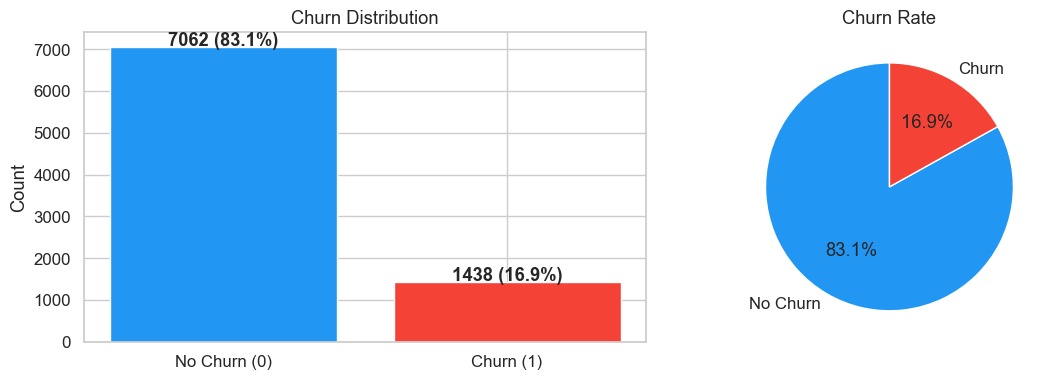

Imbalance ratio: 4.9:1
=> Use class_weight=balanced or scale_pos_weight~5 for XGBoost


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df["churn"].value_counts().sort_index()
labels = ["No Churn (0)", "Churn (1)"]
colors = ["#2196F3", "#F44336"]

axes[0].bar(labels, churn_counts.values, color=colors)
axes[0].set_title("Churn Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f"{v} ({v/len(df):.1%})", ha="center", fontweight="bold")

axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Churn Rate")

plt.tight_layout()
plt.savefig("../../docs/eda_class_distribution.png", dpi=120)
plt.show()

print(f"Imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1")
print("=> Use class_weight=balanced or scale_pos_weight~5 for XGBoost")

## 4. Key Numeric Feature Distributions

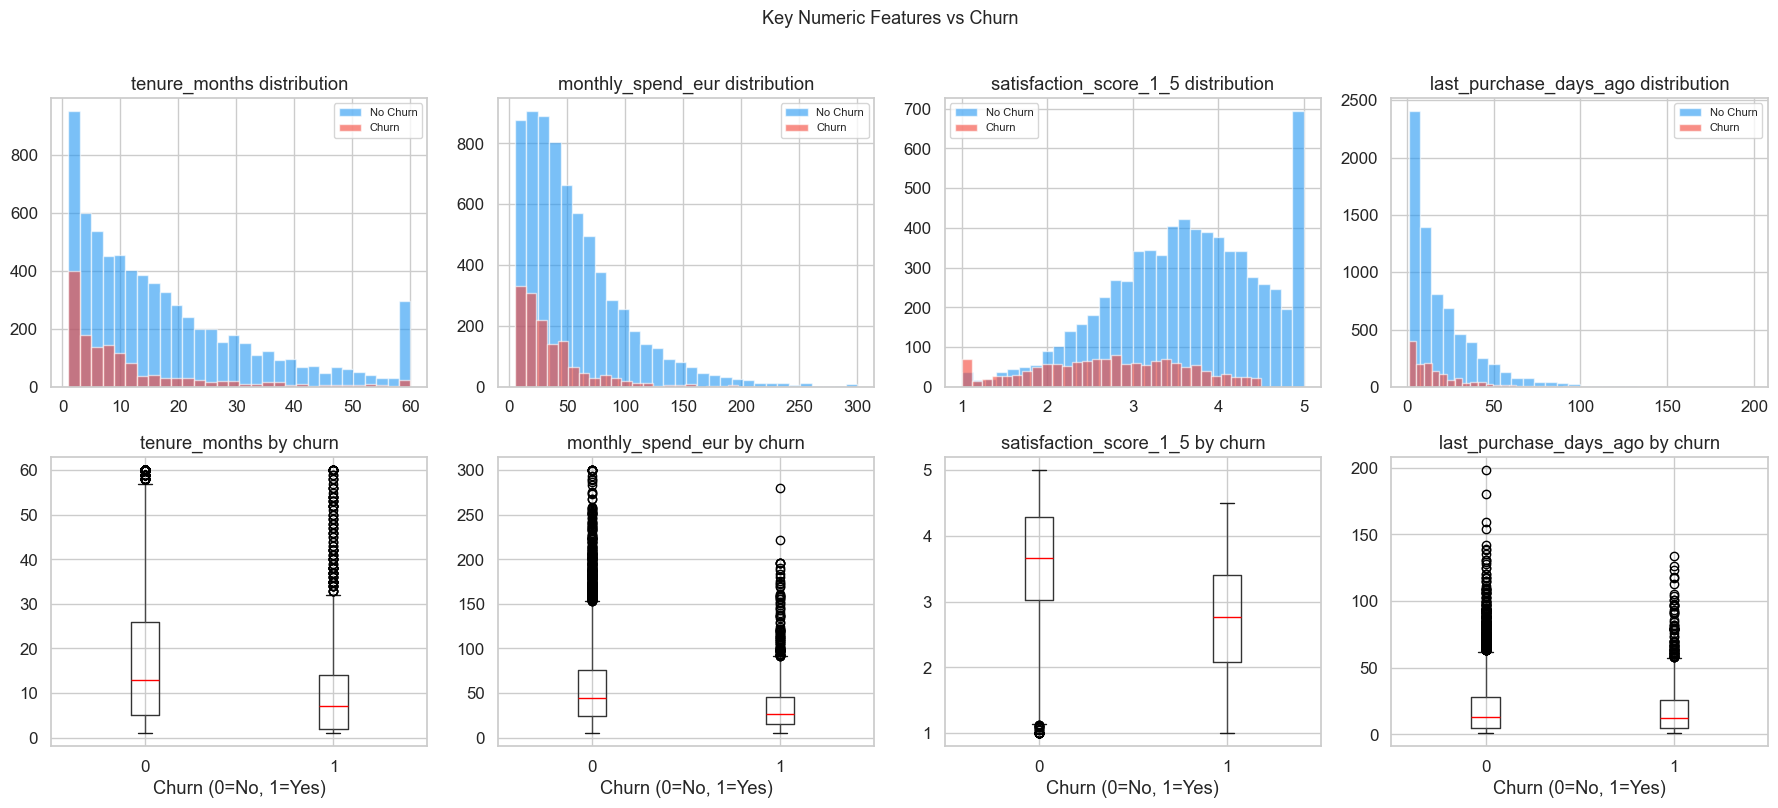

In [5]:
key_numeric = [
    "tenure_months", "monthly_spend_eur",
    "satisfaction_score_1_5", "last_purchase_days_ago"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(key_numeric):
    ax = axes[0, i]
    df[df["churn"]==0][col].hist(ax=ax, alpha=0.6, label="No Churn", color="#2196F3", bins=30)
    df[df["churn"]==1][col].hist(ax=ax, alpha=0.6, label="Churn", color="#F44336", bins=30)
    ax.set_title(col + " distribution")
    ax.legend(fontsize=8)

    ax2 = axes[1, i]
    df.boxplot(column=col, by="churn", ax=ax2,
               boxprops=dict(color="#333"), medianprops=dict(color="red"))
    ax2.set_title(col + " by churn")
    ax2.set_xlabel("Churn (0=No, 1=Yes)")

plt.suptitle("Key Numeric Features vs Churn", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("../../docs/eda_numeric_distributions.png", dpi=120)
plt.show()

## 5. Feature Correlations with Churn

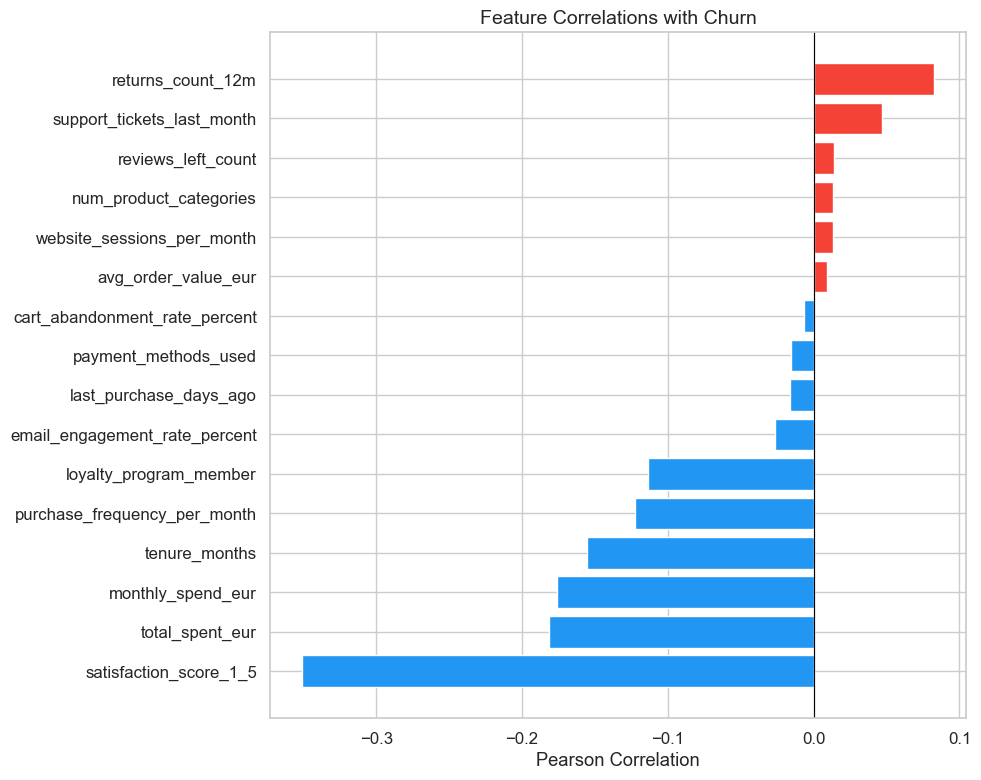

Top positive (churn risk):
website_sessions_per_month    0.013131
num_product_categories        0.013267
reviews_left_count            0.013998
support_tickets_last_month    0.047033
returns_count_12m             0.082805

Top negative (churn protection):
satisfaction_score_1_5         -0.351069
total_spent_eur                -0.181513
monthly_spend_eur              -0.175769
tenure_months                  -0.155693
purchase_frequency_per_month   -0.122565


In [6]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
corr_with_churn = df[numeric_cols].corr()["churn"].drop("churn").sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#F44336" if v > 0 else "#2196F3" for v in corr_with_churn.values]
ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlations with Churn", fontsize=14)
ax.set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.savefig("../../docs/eda_correlation_matrix.png", dpi=120)
plt.show()

print("Top positive (churn risk):")
print(corr_with_churn.tail(5).to_string())
print()
print("Top negative (churn protection):")
print(corr_with_churn.head(5).to_string())

## 6. Subscription Type vs Churn

                   Churn Rate  Count
subscription_type                   
Basic                0.309843   1717
Standard             0.159557   4243
Premium              0.090157   2540


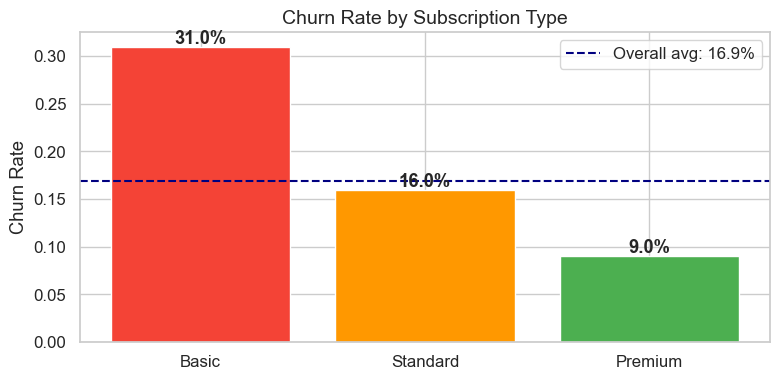

In [7]:
sub_churn = df.groupby("subscription_type")["churn"].agg(["mean", "count"])
sub_churn.columns = ["Churn Rate", "Count"]
sub_churn = sub_churn.sort_values("Churn Rate", ascending=False)
print(sub_churn.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#F44336", "#FF9800", "#4CAF50"]
bars = ax.bar(sub_churn.index, sub_churn["Churn Rate"], color=colors)
ax.set_title("Churn Rate by Subscription Type", fontsize=14)
ax.set_ylabel("Churn Rate")
ax.axhline(df["churn"].mean(), color="navy", linestyle="--",
           label=f"Overall avg: {df['churn'].mean():.1%}")
ax.legend()
for bar, v in zip(bars, sub_churn["Churn Rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
            f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../../docs/eda_categorical_churn_rates.png", dpi=120)
plt.show()

## 7. Satisfaction Score — Strongest Predictor

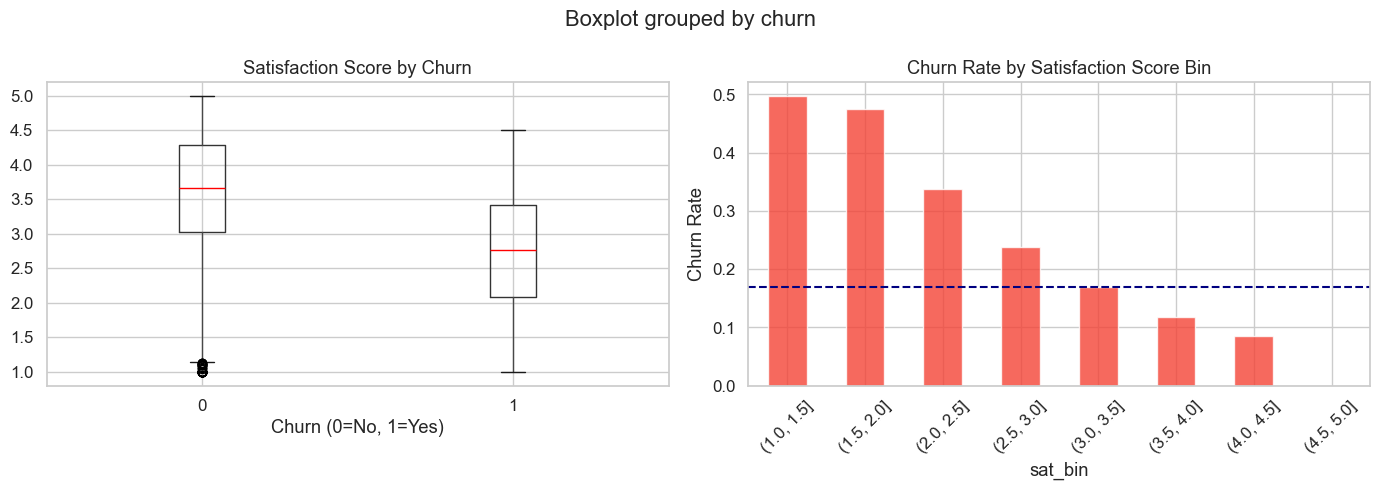

Satisfaction score correlation with churn: -0.351


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column="satisfaction_score_1_5", by="churn", ax=axes[0],
           boxprops=dict(color="#333"), medianprops=dict(color="red"))
axes[0].set_title("Satisfaction Score by Churn")
axes[0].set_xlabel("Churn (0=No, 1=Yes)")

bins = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
df["sat_bin"] = pd.cut(df["satisfaction_score_1_5"], bins=bins)
churn_by_sat = df.groupby("sat_bin", observed=True)["churn"].mean()
churn_by_sat.plot(kind="bar", ax=axes[1], color="#F44336", alpha=0.8)
axes[1].set_title("Churn Rate by Satisfaction Score Bin")
axes[1].set_ylabel("Churn Rate")
axes[1].axhline(df["churn"].mean(), color="navy", linestyle="--")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../../docs/eda_contract_analysis.png", dpi=120)
plt.show()

print("Satisfaction score correlation with churn:",
      f"{df['satisfaction_score_1_5'].corr(df['churn']):.3f}")

## 8. Tenure Cohort Analysis

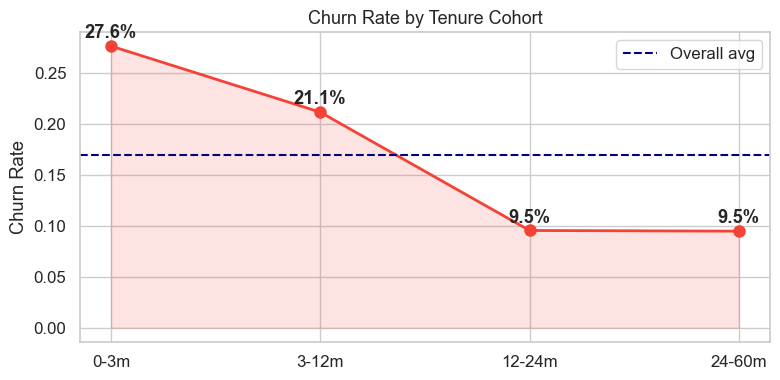

=> New customers (0-3m) churn at highest rate — early lifecycle risk!


In [9]:
df["tenure_bin"] = pd.cut(df["tenure_months"],
                          bins=[0, 3, 12, 24, 60],
                          labels=["0-3m", "3-12m", "12-24m", "24-60m"])

cohort_churn = df.groupby("tenure_bin", observed=True)["churn"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cohort_churn.index, cohort_churn.values, "o-",
        color="#F44336", linewidth=2, markersize=8)
ax.fill_between(range(len(cohort_churn)), cohort_churn.values, alpha=0.15, color="#F44336")
ax.set_title("Churn Rate by Tenure Cohort", fontsize=13)
ax.set_ylabel("Churn Rate")
ax.set_xticks(range(len(cohort_churn)))
ax.set_xticklabels(cohort_churn.index)
for i, v in enumerate(cohort_churn.values):
    ax.text(i, v + 0.008, f"{v:.1%}", ha="center", fontweight="bold")
ax.axhline(df["churn"].mean(), color="navy", linestyle="--", label="Overall avg")
ax.legend()
plt.tight_layout()
plt.savefig("../../docs/eda_tenure_cohort.png", dpi=120)
plt.show()

print("=> New customers (0-3m) churn at highest rate — early lifecycle risk!")

## 9. Geographic and Category Analysis

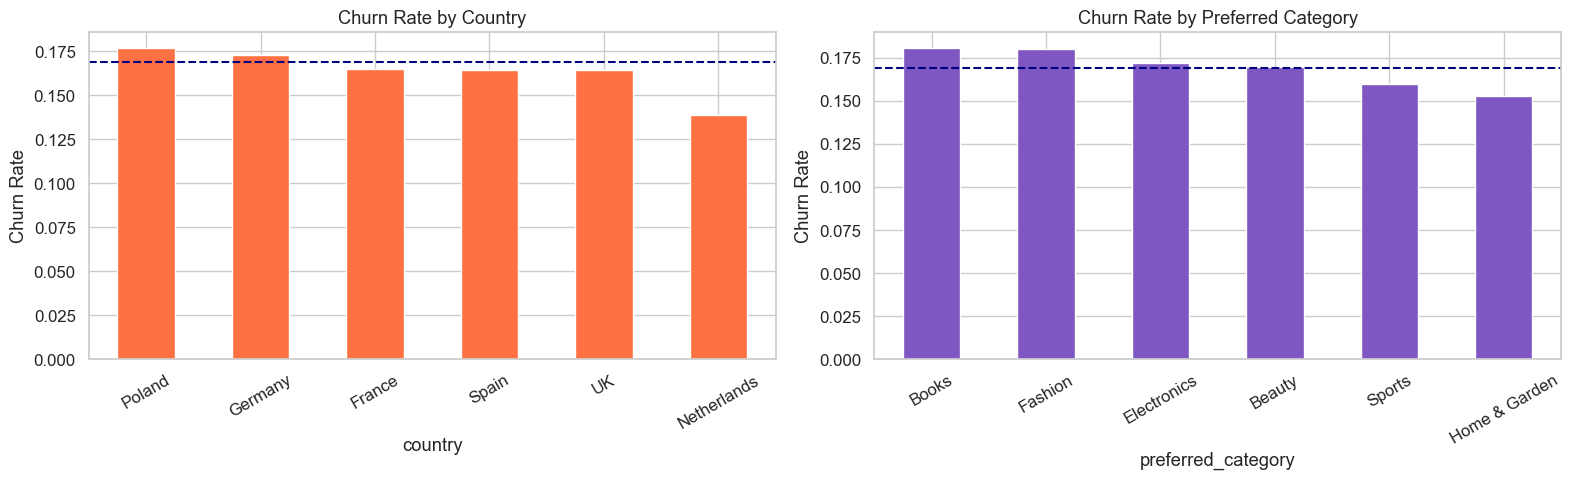

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_churn = df.groupby("country")["churn"].mean().sort_values(ascending=False)
country_churn.plot(kind="bar", ax=axes[0], color="#FF7043")
axes[0].set_title("Churn Rate by Country")
axes[0].set_ylabel("Churn Rate")
axes[0].axhline(df["churn"].mean(), color="navy", linestyle="--")
axes[0].tick_params(axis="x", rotation=30)

cat_churn = df.groupby("preferred_category")["churn"].mean().sort_values(ascending=False)
cat_churn.plot(kind="bar", ax=axes[1], color="#7E57C2")
axes[1].set_title("Churn Rate by Preferred Category")
axes[1].set_ylabel("Churn Rate")
axes[1].axhline(df["churn"].mean(), color="navy", linestyle="--")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../../docs/eda_numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. EDA Summary & Modeling Implications

### Key Findings

| Finding | Impact on Model |
|---------|----------------|
| **Class imbalance: 83.1% / 16.9%** | Use `class_weight='balanced'`, XGBoost `scale_pos_weight=5` |
| **Satisfaction score: -0.351 corr with churn** | Strongest single predictor |
| **Short tenure (0-3m): highest churn** | tenure_months critical numeric feature |
| **Basic subscription: highest churn** | subscription_type top categorical |
| **High returns & support tickets → more churn** | positive-corr features |
| **No missing values** | Clean dataset, no imputation needed |

### Feature Engineering Decisions
- **OneHotEncoder** for 4 categoricals: country, account_age_category, subscription_type, preferred_category
- **StandardScaler** for 16 numeric features
- **Drop**: customer_id (ID), registration_date (redundant with tenure_months)

### Model Expectations
- AUC-ROC > 0.85 expected (stronger signal than Telco dataset — satisfaction_score dominates)
- F1 ~0.55-0.65 given 16.9% class imbalance
- XGBoost expected best (nonlinear interactions: tenure × satisfaction × spend)